# HyDMIS — LIAR2 EDA
## Political Disinformation Domain

**Dataset:** LIAR2 — Xu & Kechadi (2024), updated PolitiFact benchmark  
**Records:** 22,962  
**Labels:** Six-way veracity (0=pants-fire → 5=true)  
**Domain:** Political disinformation, English  

**Label mapping:**
- 0 = pants-fire (most false)
- 1 = false
- 2 = barely-true
- 3 = half-true
- 4 = mostly-true
- 5 = true

**Key findings:** 57.7% binary disinformation rate. Social media sources show 93.8% disinformation rate vs politicians at 48.1%. Disinformation rate rose from 41.7% (2008) to 87.4% (2023) — sustained post-2017 increase driven by social media fact-checking expansion.

In [1]:
import sys
import os
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from liar2_loader import load_liar2

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
os.makedirs('../figures/eda', exist_ok=True)

LABEL_NAMES = {0:'pants-fire', 1:'false', 2:'barely-true',
               3:'half-true', 4:'mostly-true', 5:'true'}
BINARY_MAP = {0:1, 1:1, 2:1, 3:0, 4:0, 5:0}
LABEL_COLORS = ['#8B0000','#d9534f','#f0ad4e','#f0e68c','#90EE90','#5cb85c']
print('Imports complete')

Imports complete


In [2]:
result = load_liar2(data_dir='../data/raw')
df = result['data']
df['label_name'] = df['label'].map(LABEL_NAMES)
df['binary_label'] = df['label'].map(BINARY_MAP)
df['statement_len'] = df['statement'].astype(str).str.len()
df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce')
df['year'] = df['date_parsed'].dt.year

def get_speaker_type(speaker):
    speaker = str(speaker).lower()
    if any(x in speaker for x in ['facebook','instagram','twitter','viral','social']):
        return 'Social Media'
    elif any(x in speaker for x in ['blog','chain email','email']):
        return 'Blogs/Email'
    elif any(x in speaker for x in ['donald trump','barack obama','hillary clinton',
                                      'joe biden','mitt romney','bernie sanders']):
        return 'Major Politicians'
    elif any(x in speaker for x in ['governor','senator','representative','mayor']):
        return 'State Politicians'
    else:
        return 'Other'
df['speaker_type'] = df['speaker'].apply(get_speaker_type)

print(f'Shape: {df.shape}')
print(f'Disinformation rate: {df["binary_label"].mean():.1%}')
print(f'Records: {len(df):,}')

Loading LIAR2...


  ✓ LIAR2: 22,962 records | Political | English
Shape: (22962, 23)
Disinformation rate: 57.7%
Records: 22,962


## 1. Six-Way Label Distribution

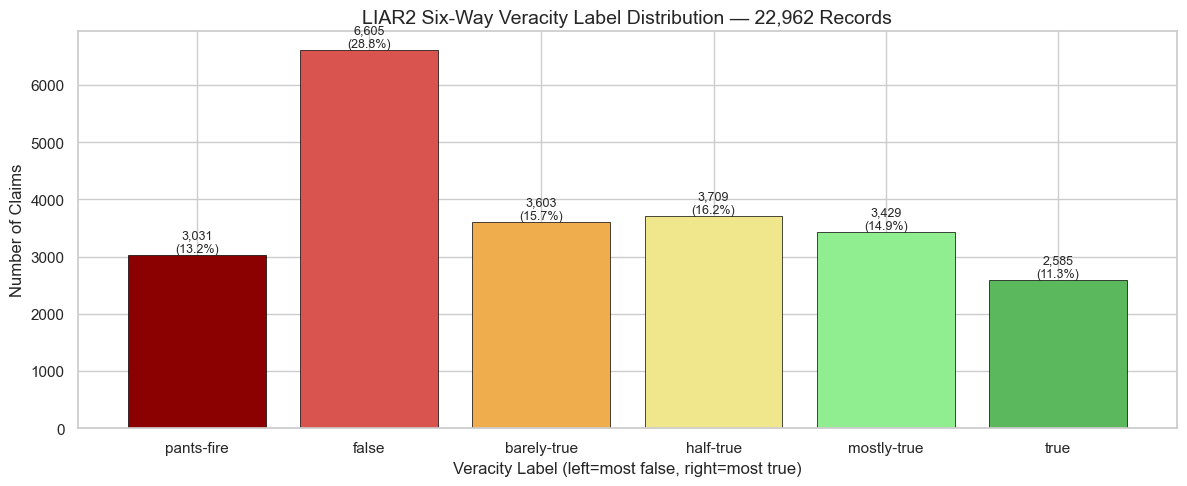

Label 1 (false) dominates at 28.8% — most common claim type


In [3]:
label_counts = df['label'].value_counts().sort_index()
label_names = [LABEL_NAMES[i] for i in range(6)]

fig, ax = plt.subplots(figsize=(12,5))
bars = ax.bar(label_names, [label_counts[i] for i in range(6)],
              color=LABEL_COLORS, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, [label_counts[i] for i in range(6)]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            f'{val:,}\n({val/len(df):.1%})', ha='center', fontsize=9)
ax.set_title('LIAR2 Six-Way Veracity Label Distribution — 22,962 Records', fontsize=14)
ax.set_ylabel('Number of Claims')
ax.set_xlabel('Veracity Label (left=most false, right=most true)')
plt.tight_layout()
plt.savefig('../figures/eda/liar2_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Label 1 (false) dominates at 28.8% — most common claim type')

## 2. Binary Disinformation Rate

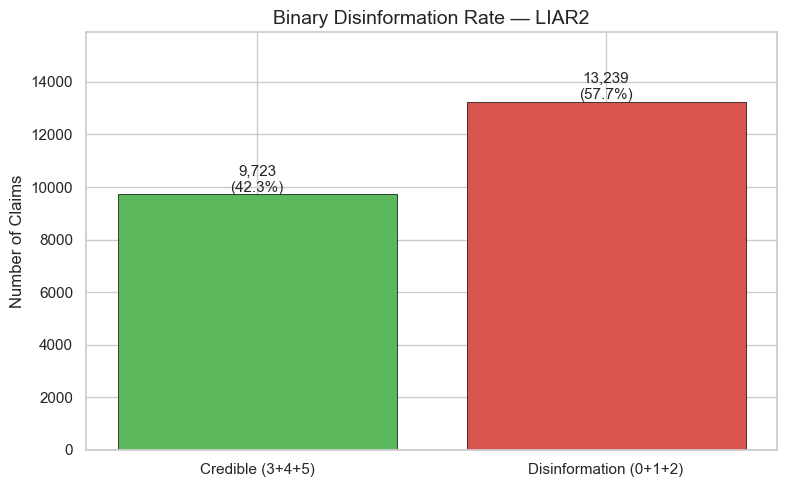

57.7% disinformation rate — majority of political claims are false or misleading


In [4]:
binary_counts = df['binary_label'].value_counts().sort_index()
binary_labels = ['Credible (3+4+5)', 'Disinformation (0+1+2)']

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(binary_labels, [binary_counts[0], binary_counts[1]],
              color=['#5cb85c','#d9534f'], edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, [binary_counts[0], binary_counts[1]]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
            f'{val:,}\n({val/len(df):.1%})', ha='center', fontsize=11)
ax.set_title('Binary Disinformation Rate — LIAR2', fontsize=14)
ax.set_ylabel('Number of Claims')
ax.set_ylim(0, max(binary_counts.values)*1.2)
plt.tight_layout()
plt.savefig('../figures/eda/liar2_binary_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'57.7% disinformation rate — majority of political claims are false or misleading')

## 3. Split Distribution

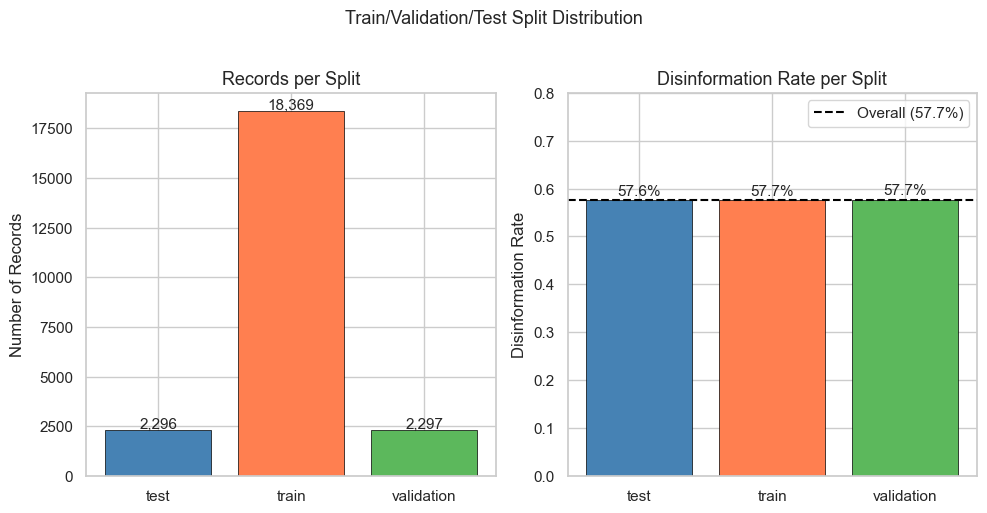

Consistent disinformation rate across splits — good benchmark quality


In [5]:
split_stats = df.groupby('split').agg(
    count=('binary_label','count'),
    dis_rate=('binary_label','mean')
).reset_index()

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
colors = ['steelblue','coral','#5cb85c']

ax1.bar(split_stats['split'], split_stats['count'], color=colors, edgecolor='black', linewidth=0.5)
ax1.set_title('Records per Split', fontsize=13)
ax1.set_ylabel('Number of Records')
for i, (_, row) in enumerate(split_stats.iterrows()):
    ax1.text(i, row['count']+100, f'{int(row["count"]):,}', ha='center', fontsize=11)

ax2.bar(split_stats['split'], split_stats['dis_rate'], color=colors, edgecolor='black', linewidth=0.5)
ax2.axhline(y=df['binary_label'].mean(), color='black', linestyle='--', linewidth=1.5,
            label=f'Overall ({df["binary_label"].mean():.1%})')
ax2.set_title('Disinformation Rate per Split', fontsize=13)
ax2.set_ylabel('Disinformation Rate')
ax2.set_ylim(0, 0.8)
ax2.legend()
for i, (_, row) in enumerate(split_stats.iterrows()):
    ax2.text(i, row['dis_rate']+0.01, f'{row["dis_rate"]:.1%}', ha='center', fontsize=11)

plt.suptitle('Train/Validation/Test Split Distribution', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/liar2_split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Consistent disinformation rate across splits — good benchmark quality')

## 4. Top 15 Speakers by Disinformation Rate

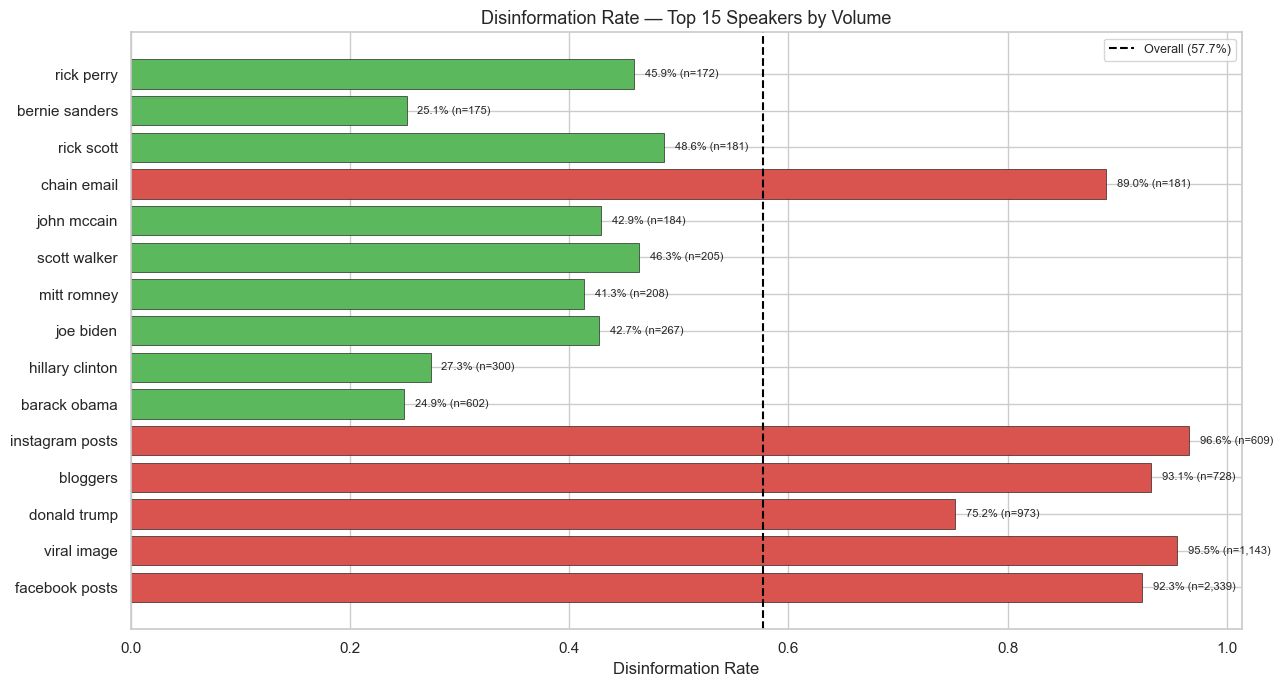

Instagram posts 96.6% | Facebook posts 92.3% | Barack Obama 24.9%


In [6]:
speaker_stats = df.groupby('speaker').agg(
    count=('binary_label','count'),
    dis_rate=('binary_label','mean')
).reset_index().sort_values('count', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(13,7))
colors = ['#d9534f' if r > 0.5 else '#5cb85c' for r in speaker_stats['dis_rate']]
bars = ax.barh(speaker_stats['speaker'], speaker_stats['dis_rate'],
               color=colors, edgecolor='black', linewidth=0.4)
ax.axvline(x=df['binary_label'].mean(), color='black', linestyle='--', linewidth=1.5,
           label=f'Overall ({df["binary_label"].mean():.1%})')
ax.set_title('Disinformation Rate — Top 15 Speakers by Volume', fontsize=13)
ax.set_xlabel('Disinformation Rate')
ax.legend(fontsize=9)
for bar, (_, row) in zip(bars, speaker_stats.iterrows()):
    ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
            f'{row["dis_rate"]:.1%} (n={int(row["count"]):,})', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../figures/eda/liar2_speakers.png', dpi=150, bbox_inches='tight')
plt.show()
print('Instagram posts 96.6% | Facebook posts 92.3% | Barack Obama 24.9%')

## 5. Top 15 Subjects by Disinformation Rate

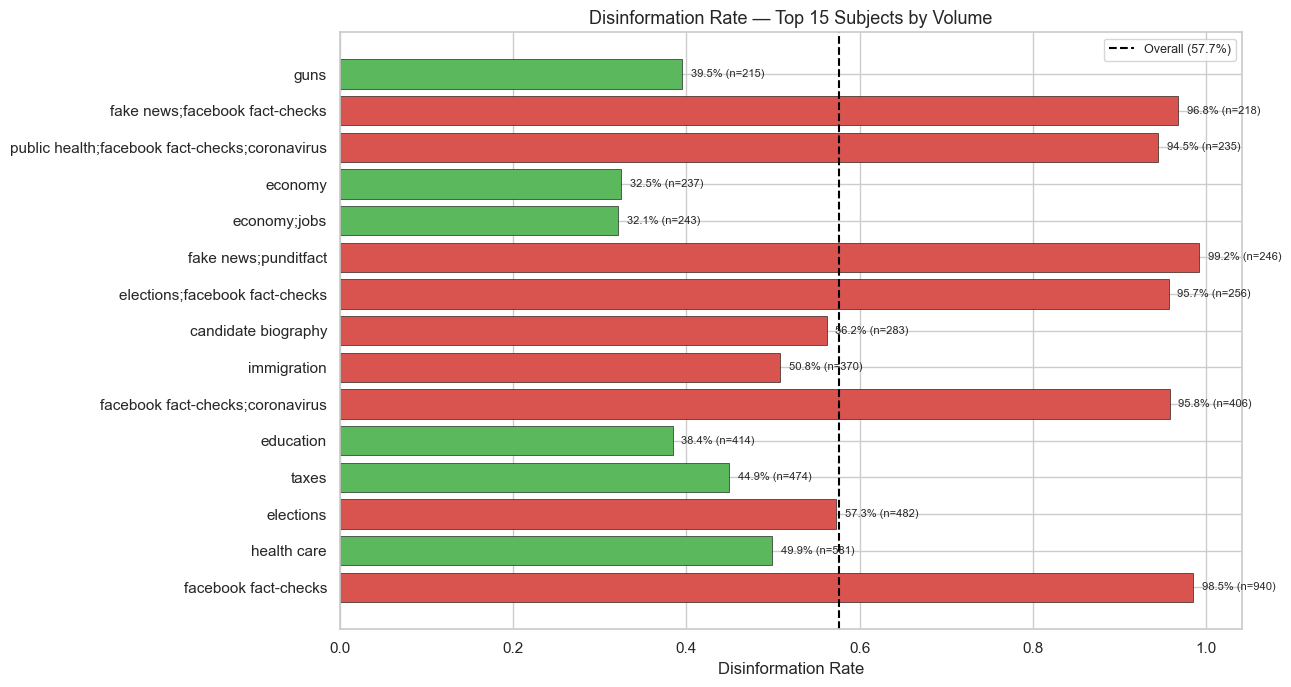

Facebook fact-checks 98.5% | fake news 99.2% | economy 32.5%


In [7]:
subject_stats = df.groupby('subject').agg(
    count=('binary_label','count'),
    dis_rate=('binary_label','mean')
).reset_index().sort_values('count', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(13,7))
colors = ['#d9534f' if r > 0.5 else '#5cb85c' for r in subject_stats['dis_rate']]
bars = ax.barh(subject_stats['subject'], subject_stats['dis_rate'],
               color=colors, edgecolor='black', linewidth=0.4)
ax.axvline(x=df['binary_label'].mean(), color='black', linestyle='--', linewidth=1.5,
           label=f'Overall ({df["binary_label"].mean():.1%})')
ax.set_title('Disinformation Rate — Top 15 Subjects by Volume', fontsize=13)
ax.set_xlabel('Disinformation Rate')
ax.legend(fontsize=9)
for bar, (_, row) in zip(bars, subject_stats.iterrows()):
    ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
            f'{row["dis_rate"]:.1%} (n={int(row["count"]):,})', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../figures/eda/liar2_subjects.png', dpi=150, bbox_inches='tight')
plt.show()
print('Facebook fact-checks 98.5% | fake news 99.2% | economy 32.5%')

## 6. State Distribution and Disinformation Rate

Note: 24.6% of records have missing state_info — shown separately.

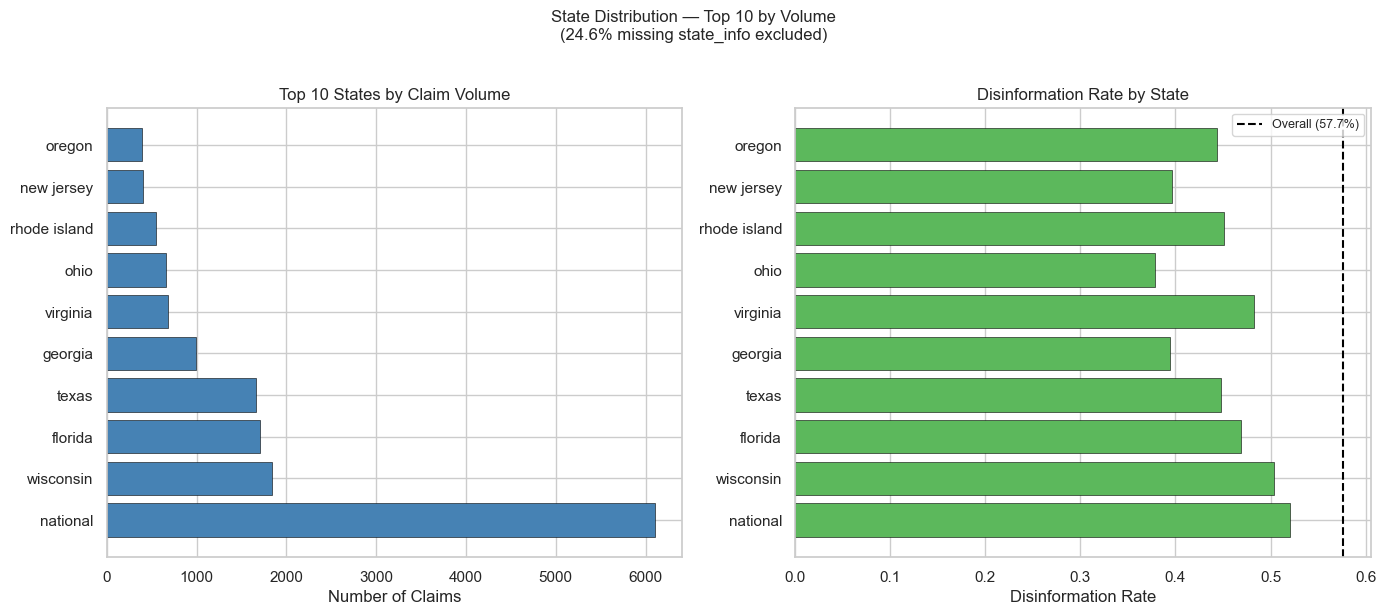

In [8]:
state_stats = df[df['state_info'].notna()].groupby('state_info').agg(
    count=('binary_label','count'),
    dis_rate=('binary_label','mean')
).reset_index().sort_values('count', ascending=False).head(10)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,6))

ax1.barh(state_stats['state_info'], state_stats['count'],
         color='steelblue', edgecolor='black', linewidth=0.4)
ax1.set_title('Top 10 States by Claim Volume', fontsize=12)
ax1.set_xlabel('Number of Claims')

colors = ['#d9534f' if r > df['binary_label'].mean() else '#5cb85c'
          for r in state_stats['dis_rate']]
ax2.barh(state_stats['state_info'], state_stats['dis_rate'],
         color=colors, edgecolor='black', linewidth=0.4)
ax2.axvline(x=df['binary_label'].mean(), color='black', linestyle='--', linewidth=1.5,
            label=f'Overall ({df["binary_label"].mean():.1%})')
ax2.set_title('Disinformation Rate by State', fontsize=12)
ax2.set_xlabel('Disinformation Rate')
ax2.legend(fontsize=9)

plt.suptitle('State Distribution — Top 10 by Volume\n(24.6% missing state_info excluded)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/liar2_states.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Speaker History Credibility Heatmap

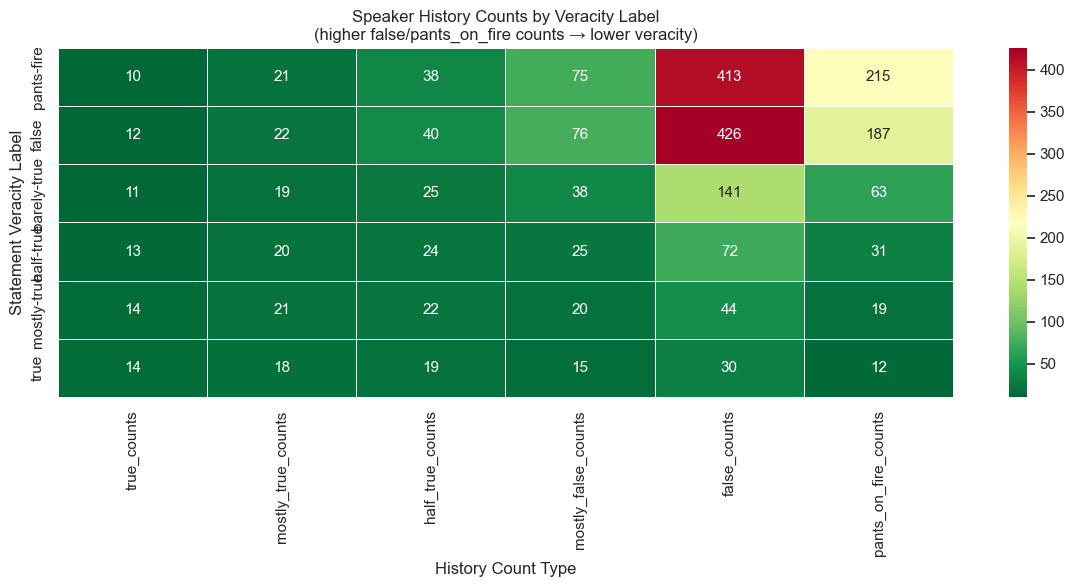

Speaker history is a strong signal — pants-fire speakers have 413 avg false_counts


In [9]:
hist_cols = ['true_counts','mostly_true_counts','half_true_counts',
             'mostly_false_counts','false_counts','pants_on_fire_counts']
hist_means = df.groupby('label')[hist_cols].mean()
hist_means.index = [LABEL_NAMES[i] for i in hist_means.index]

fig, ax = plt.subplots(figsize=(12,6))
sns.heatmap(hist_means, annot=True, fmt='.0f', cmap='RdYlGn_r',
            ax=ax, linewidths=0.5)
ax.set_title('Speaker History Counts by Veracity Label\n'
             '(higher false/pants_on_fire counts → lower veracity)', fontsize=12)
ax.set_xlabel('History Count Type')
ax.set_ylabel('Statement Veracity Label')
plt.tight_layout()
plt.savefig('../figures/eda/liar2_speaker_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Speaker history is a strong signal — pants-fire speakers have 413 avg false_counts')

## 8. Statement Length by Veracity Label

Shorter statements tend to be more false — pants-fire claims average 96 chars vs half-true at 115.

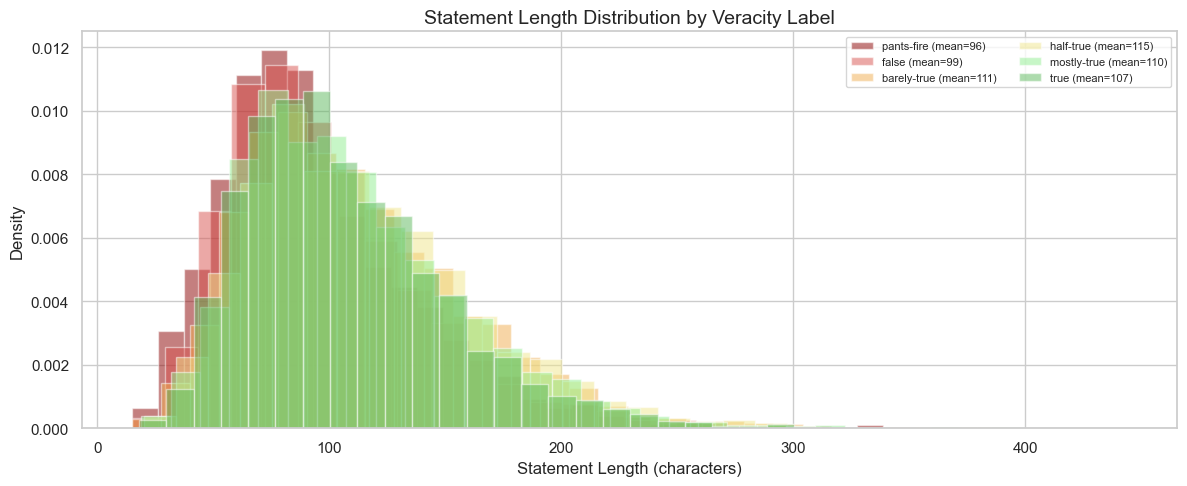

pants-fire: 96 chars | half-true: 115 chars — shorter = more false (r=-0.102)


In [10]:
fig, ax = plt.subplots(figsize=(12,5))
for i, label in enumerate(range(6)):
    subset = df[df['label']==label]['statement_len']
    ax.hist(subset, bins=30, alpha=0.5, color=LABEL_COLORS[i],
            label=f'{LABEL_NAMES[label]} (mean={subset.mean():.0f})', density=True)
ax.set_title('Statement Length Distribution by Veracity Label', fontsize=14)
ax.set_xlabel('Statement Length (characters)')
ax.set_ylabel('Density')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('../figures/eda/liar2_statement_length.png', dpi=150, bbox_inches='tight')
plt.show()
print('pants-fire: 96 chars | half-true: 115 chars — shorter = more false (r=-0.102)')

## 9. Temporal Trend — Disinformation Rate by Year

Disinformation rate rose from 41.7% (2008) to 87.4% (2023). 2020 spike (77.9%) reflects COVID-19 misinformation + US presidential election. Post-2017 sustained rise driven by social media fact-checking expansion in LIAR2.

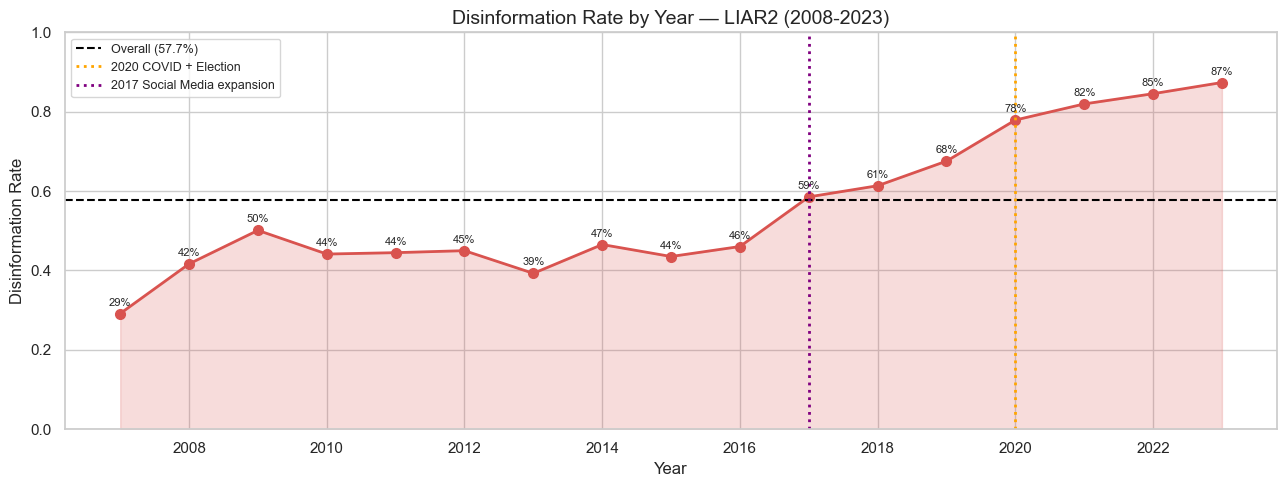

In [11]:
year_stats = df.groupby('year').agg(
    count=('binary_label','count'),
    dis_rate=('binary_label','mean')
).reset_index().dropna()
year_stats = year_stats[year_stats['count'] >= 100]

fig, ax = plt.subplots(figsize=(13,5))
ax.plot(year_stats['year'], year_stats['dis_rate'], 'o-',
        color='#d9534f', linewidth=2, markersize=7)
ax.fill_between(year_stats['year'], year_stats['dis_rate'],
                alpha=0.2, color='#d9534f')
ax.axhline(y=df['binary_label'].mean(), color='black', linestyle='--', linewidth=1.5,
           label=f'Overall ({df["binary_label"].mean():.1%})')
ax.axvline(x=2020, color='orange', linestyle=':', linewidth=2, label='2020 COVID + Election')
ax.axvline(x=2017, color='purple', linestyle=':', linewidth=2, label='2017 Social Media expansion')
ax.set_title('Disinformation Rate by Year — LIAR2 (2008-2023)', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Disinformation Rate')
ax.set_ylim(0, 1.0)
ax.legend(fontsize=9)
for _, row in year_stats.iterrows():
    ax.text(row['year'], row['dis_rate']+0.02, f'{row["dis_rate"]:.0%}',
            ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('../figures/eda/liar2_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Speaker Type vs Disinformation Rate

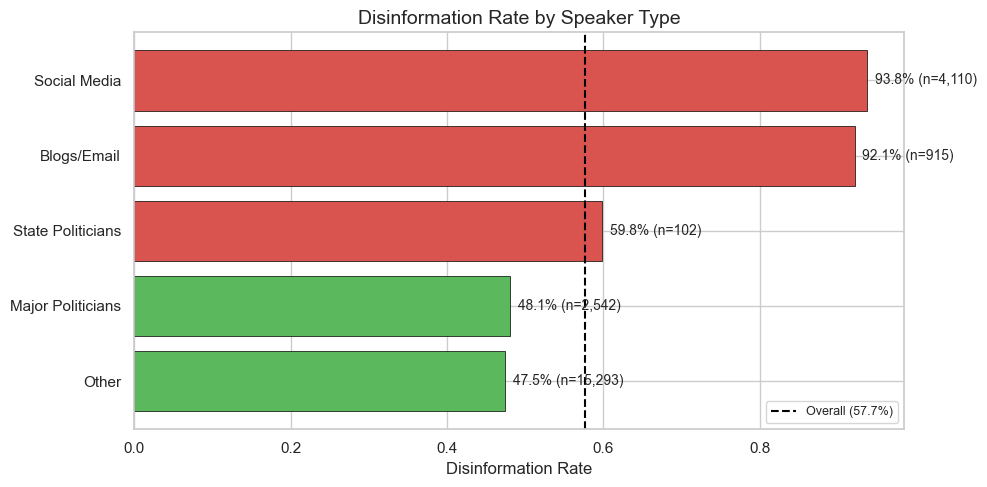

Social Media 93.8% vs Major Politicians 48.1% — structural difference


In [12]:
type_stats = df.groupby('speaker_type').agg(
    count=('binary_label','count'),
    dis_rate=('binary_label','mean')
).reset_index().sort_values('dis_rate', ascending=True)

fig, ax = plt.subplots(figsize=(10,5))
colors = ['#d9534f' if r > 0.5 else '#5cb85c' for r in type_stats['dis_rate']]
bars = ax.barh(type_stats['speaker_type'], type_stats['dis_rate'],
               color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(x=df['binary_label'].mean(), color='black', linestyle='--', linewidth=1.5,
           label=f'Overall ({df["binary_label"].mean():.1%})')
ax.set_title('Disinformation Rate by Speaker Type', fontsize=14)
ax.set_xlabel('Disinformation Rate')
ax.legend(fontsize=9)
for bar, (_, row) in zip(bars, type_stats.iterrows()):
    ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
            f'{row["dis_rate"]:.1%} (n={int(row["count"]):,})', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../figures/eda/liar2_speaker_type.png', dpi=150, bbox_inches='tight')
plt.show()
print('Social Media 93.8% vs Major Politicians 48.1% — structural difference')

## 11. Disinformation Severity Spectrum

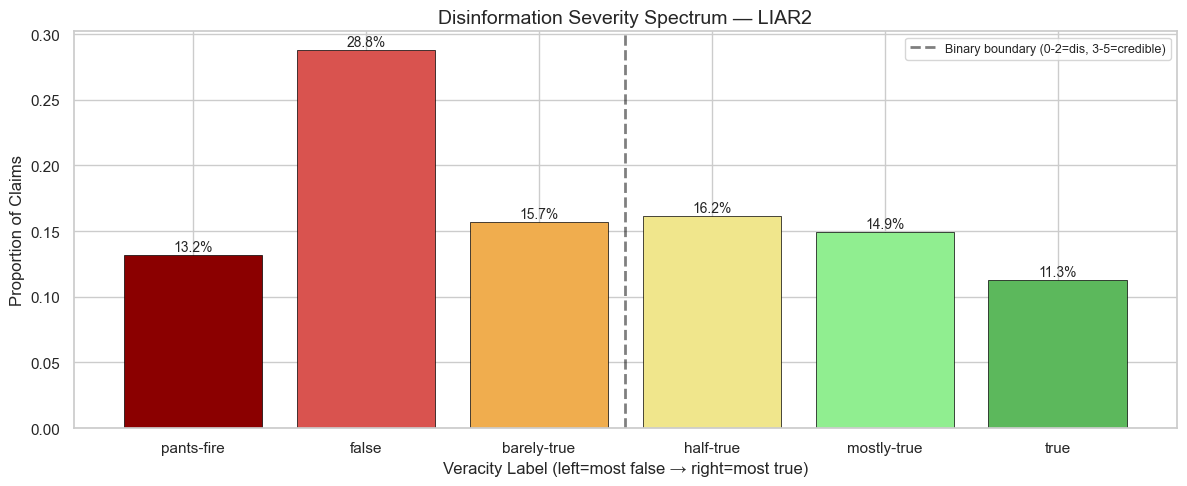

In [13]:
# Show the spectrum from pants-fire to true with disinformation rate
severity = pd.DataFrame({
    'label': range(6),
    'name': [LABEL_NAMES[i] for i in range(6)],
    'count': [label_counts[i] for i in range(6)],
    'pct': [label_counts[i]/len(df) for i in range(6)]
})

fig, ax = plt.subplots(figsize=(12,5))
bars = ax.bar(severity['name'], severity['pct'],
              color=LABEL_COLORS, edgecolor='black', linewidth=0.5)
ax.axvline(x=2.5, color='black', linewidth=2, linestyle='--', alpha=0.5,
           label='Binary boundary (0-2=dis, 3-5=credible)')
ax.set_title('Disinformation Severity Spectrum — LIAR2', fontsize=14)
ax.set_ylabel('Proportion of Claims')
ax.set_xlabel('Veracity Label (left=most false → right=most true)')
ax.legend(fontsize=9)
for bar, (_, row) in zip(bars, severity.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{row["pct"]:.1%}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../figures/eda/liar2_severity_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Missing Values Summary

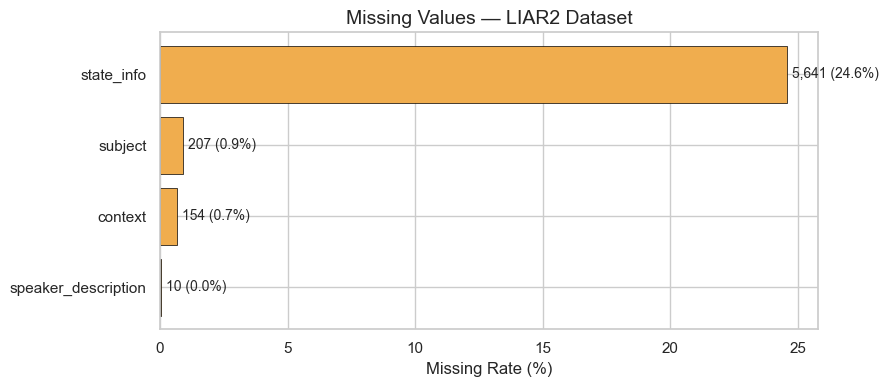

state_info 24.6% missing — most significant gap


In [14]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9,4))
bars = ax.barh(missing.index, missing.values/len(df)*100,
               color='#f0ad4e', edgecolor='black', linewidth=0.5)
ax.set_title('Missing Values — LIAR2 Dataset', fontsize=14)
ax.set_xlabel('Missing Rate (%)')
for bar, val in zip(bars, missing.values):
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f'{val:,} ({val/len(df):.1%})', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../figures/eda/liar2_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('state_info 24.6% missing — most significant gap')

## 13. Key Observations

**Disinformation dominates:** 57.7% binary disinformation rate across 22,962 claims. Label 1 (false) is most common at 28.8%.

**Social media vs politicians:** Social media sources show 93.8% disinformation rate vs Major Politicians at 48.1%. Barack Obama (24.9%) and Bernie Sanders (25.1%) have lowest disinformation rates among named speakers.

**Temporal escalation:** Disinformation rate rose from 41.7% (2008) to 87.4% (2023). 2020 spike (77.9%) reflects COVID-19 + presidential election. Post-2017 sustained rise driven by social media fact-checking expansion in LIAR2 corpus.

**Subject patterns:** Facebook fact-checks (98.5%) and fake news (99.2%) subjects are nearly all disinformation. Economy (32.5%) and education (38.4%) subjects are more credible.

**Statement length signal:** Shorter statements are more false (r=-0.102). pants-fire claims average 96 chars vs half-true at 115 chars.

**Speaker history:** Strong predictive signal — speakers with high historical false_counts continue making false claims. Used as feature in HyDMIS Stage 1 LDA.

**Missing data:** state_info missing for 24.6% of records — geographic analysis limited. HyDMIS uses text-based features not geographic ones.